### Introduction


This project performs Exploratory Data Analysis (EDA) on the US Presidential Election Results dataset from 1976 to 2020. Using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn, the project explores election trends, analyzes candidate performance, compares political parties, and answers meaningful business questions through statistical analysis and visualization.

The objective is to discover meaningful insights that can help understand historical election outcomes and voting behavior across different states.

In [1]:
# Importing Libraies
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading the CSV file and loading the dataset
a=pd.read_csv('/kaggle/input/datasets/tunguz/us-elections-dataset/1976-2020-president.csv')


In [3]:
# Creating a DataFrame from the CSV File
df=pd.DataFrame(a)


In [ ]:
# Displaying the top 10 records 
df.head(10)

In [ ]:
# Displaying the bottom 10 records
df.tail(10)

In [ ]:
# Returns the rows and columns in the dataset
df.shape

In [ ]:
# Displays 5 sample records
df.sample(5)

In [ ]:
# Displays the list of Column names in dataset
df.columns.tolist()

In [ ]:
# Returns all values in a record per columns
df.values

In [ ]:
# Displays non-null values, datatypes, memory usage info, and count of rows and columns
df.info()

In [ ]:
# Check for missing values in every column
df.isna().sum()

In [ ]:
# Check for missing value percentage

missing_val = (df.isnull().sum()/len(df))*100

missing_val.sort_values(ascending=False)

In [ ]:
# Dropping notes column

df.drop(columns='notes', inplace=True)

In [ ]:
# Filling null values in Candidate column to "No Candidate"
df['candidate']=df['candidate'].fillna("No Candidate")

In [ ]:
df['party_detailed']=df['party_detailed'].fillna("Unknown")

In [ ]:
# Checking Duplicate Records
df.duplicated().sum()      # No duplicate records

In [ ]:
# Remove duplicate if any
# df.drop_duplicates(inplace=True)

In [ ]:
# Checking unique number of values in each column

for col in df.columns:
    print(f'Column Name :{col}, Unique values: {df[col].nunique()}')

In [ ]:
# Check DataType of each columns

df.dtypes

In [ ]:
# Convert Candidate Name, state, and party_simplified columns from 'object' to 'Category' datatype to reduce memory usage
df['candidate'] = df['candidate'].astype('category')
df['state'] = df['state'].astype('category')
df['party_simplified'] = df['party_simplified'].astype('category')

### Summary Statistics

In [ ]:
# describe() calculates summary statistics for all numeric columns.

df.describe()

In [ ]:
# For numerical as well as non-numerical values
df.describe(include='all')

In [ ]:
# for non-numerical columns

df.describe(include='object')

In [ ]:
# Average of all numeric column

df.mean(numeric_only=True)

In [ ]:
# Average of all numeric column

df.mean(numeric_only=True)

In [ ]:
# Median of all numeric column

df.median(numeric_only=True)

In [ ]:
# Mode of all numeric column

df.mode(numeric_only=True)

In [ ]:
# Maximum of all numeric column

df.max(numeric_only=True)

In [ ]:
# Minimum of all numeric column

df.min(numeric_only=True)

In [ ]:
# Standard Deviation of all numeric column

df.std(numeric_only=True)

### ***Business questions and Visualizations***

1.What are the Top 10 States by Total Votes Cast?

In [5]:
votes = ( df.groupby('state')['totalvotes'].sum().sort_values(ascending=False).head(10))
votes

state
NEW YORK        1053200842
CALIFORNIA      1007277369
FLORIDA          685246872
TEXAS            506307322
ILLINOIS         500075631
OHIO             440030371
MICHIGAN         398157907
PENNSYLVANIA     361757761
NEW JERSEY       357333048
COLORADO         324033482
Name: totalvotes, dtype: int64

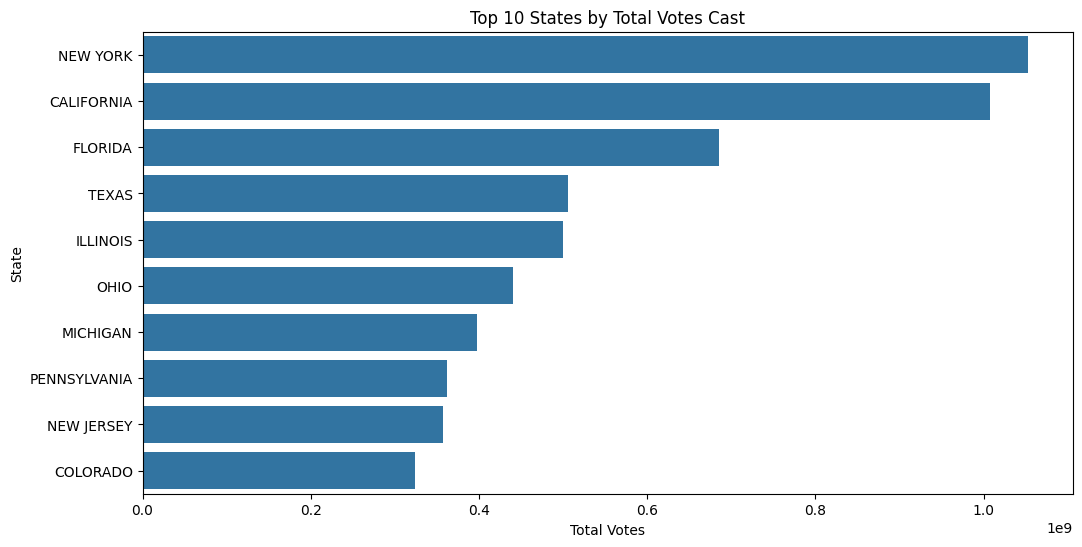

In [6]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=votes.values,
    y=votes.index
)

plt.title("Top 10 States by Total Votes Cast")
plt.xlabel("Total Votes")
plt.ylabel("State")

plt.show()

***New York has the highest share in total vote cast among the states.***

2. How has the total number of votes changed across presidential election years?

In [8]:
votes_year = df.groupby('year')['totalvotes'].sum()

votes_year

year
1976     605944064
1980     663902096
1984     609936856
1988     537099170
1992     770486377
1996     728343795
2000     783441739
2004     768259747
2008     992684830
2012     879479158
2016     941573717
2020    1865852281
Name: totalvotes, dtype: int64

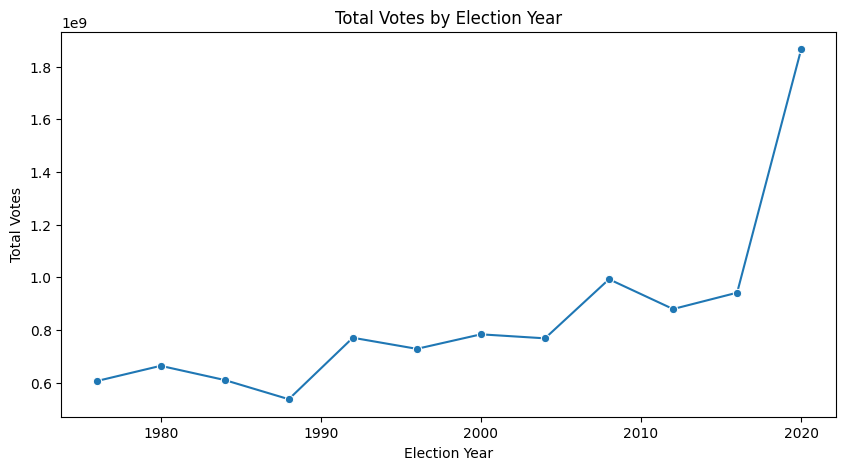

In [9]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=votes_year.index,
    y=votes_year.values,
    marker='o'
)

plt.title("Total Votes by Election Year")

plt.xlabel("Election Year")

plt.ylabel("Total Votes")

plt.show()

***Total number of votes is maximum in 2020***

3. Which candidates received the highest total votes across all elections?

In [10]:
candidates = (df.groupby('candidate')['candidatevotes'].sum().sort_values(ascending=False).head(10))
candidates.idxmax()

'TRUMP, DONALD J.'

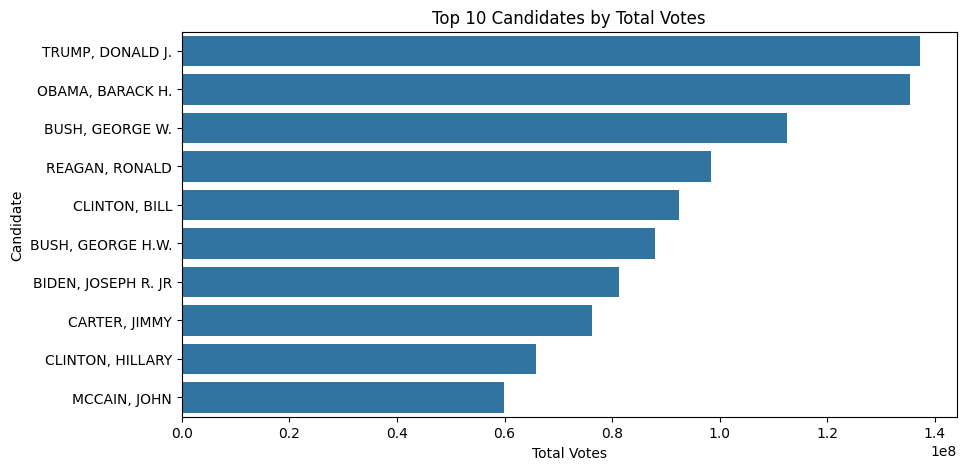

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=candidates.values,
    y=candidates.index
)

plt.title("Top 10 Candidates by Total Votes")

plt.xlabel("Total Votes")

plt.ylabel("Candidate")

plt.show()

***TRUMP received the highest total votes across all elections***

4. Which political parties have received the highest total votes?

In [13]:
votes = (df.groupby('party_simplified')['candidatevotes'].sum().sort_values(ascending=False))
votes


party_simplified
DEMOCRAT       639242184
REPUBLICAN     632502462
OTHER           54657973
LIBERTARIAN     10745232
Name: candidatevotes, dtype: int64

In [14]:
votes.idxmax()         # DEMOCRAT receives the highest vote

'DEMOCRAT'

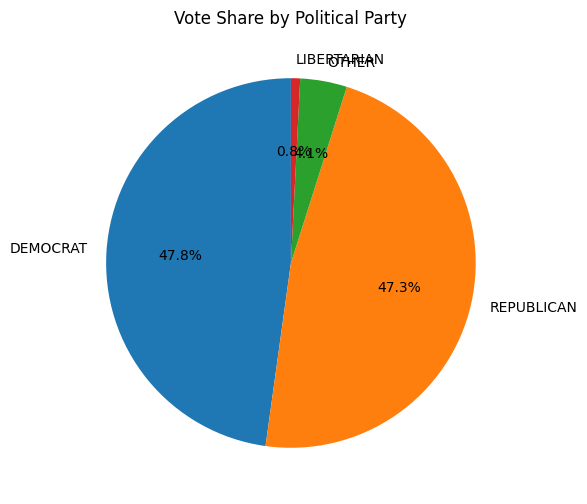

In [15]:
plt.figure(figsize=(6,6))

plt.pie(votes, labels=votes.index,autopct="%1.1f%%",startangle=90)

plt.title("Vote Share by Political Party")

plt.show()

***Democrat have received the highest total votes***

5. What is the relation between year and the vote received by the candidate?

In [ ]:
corr=df['year'].corr(df['candidatevotes'])
corr

# 0.05 means very weak positive relationship

In [ ]:
plt.figure(figsize=(10,7))

sns.regplot(data=df, 
            x='year',
            y='candidatevotes',
            scatter_kws={'alpha':0.4},
            line_kws={'color':'red'}
)

plt.title(f"Correlation={corr}")
plt.xlabel('Election Year')
plt.ylabel('Candidate Votes')

plt.show()

### Summary
This project performed Exploratory Data Analysis (EDA) on the US Presidential Election Results dataset (1976–2020) to analyze historical election trends, voting patterns, party performance, and state-wise election outcomes over multiple presidential election cycles. The dataset was cleaned and preprocessed by handling missing values, removing duplicate records, correcting data types, and ensuring consistency in columns.

Using Python, Pandas, NumPy, Matplotlib, and Seaborn, the dataset was explored through descriptive statistics, business questions, and visualizations. The analysis examined trends in total votes received by political parties, winning candidates across different election years, voter participation, state-wise voting behavior, and changes in election outcomes over time. Additional analyses compared Democratic and Republican party performances, identified states with consistently high voter turnout, and measured vote margins between winning candidates.

Several visualizations, including bar charts, line charts, scatter plots, histograms, heatmaps, and box plots, were created to present election trends and voting distributions effectively.

The project demonstrated how historical election data can be transformed into meaningful insights using data analysis techniques. The findings help explain changes in voting behavior, shifts in political support, and the evolution of electoral outcomes across different presidential elections. Such insights can assist political analysts, researchers, journalists, and policymakers in understanding electoral trends, voter preferences, and the historical performance of political parties.